<a href="https://colab.research.google.com/github/mochellez/Course_Basic-Programming-python-and-Data-Science/blob/main/sesi10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Klasifikasi**

In [ ]:
#Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder , OneHotEncoder , StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

In [ ]:
#Membuat DataFrame
df = pd.read_csv('diabetes.csv')

In [ ]:
#Tampilkan DataFrame
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**EDA**

In [ ]:
print(df.isnull().sum())
print(df.info())
print(df.describe())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: 

In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [ ]:
model = DecisionTreeClassifier(
  criterion='gini',
  max_depth= 4,
  random_state = 42)

In [ ]:
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(accuracy_score(y_test, y_pred))

0.6948051948051948


In [ ]:
pasien_baru = pd.DataFrame({
    'Pregnancies': [5],
    'Glucose': [150],
    'BloodPressure': [72],
    'SkinThickness': [35],
    'Insulin': [0],
    'BMI': [33.6],
    'DiabetesPedigreeFunction': [0.627],
    'Age': [50]
})

hasil = model.predict(pasien_baru)
print(hasil)
if hasil == 1:
  print('Pasien terkena diabetes')
else:
  print('Pasien tidak terkena diabetes')

[1]
Pasien terkena diabetes


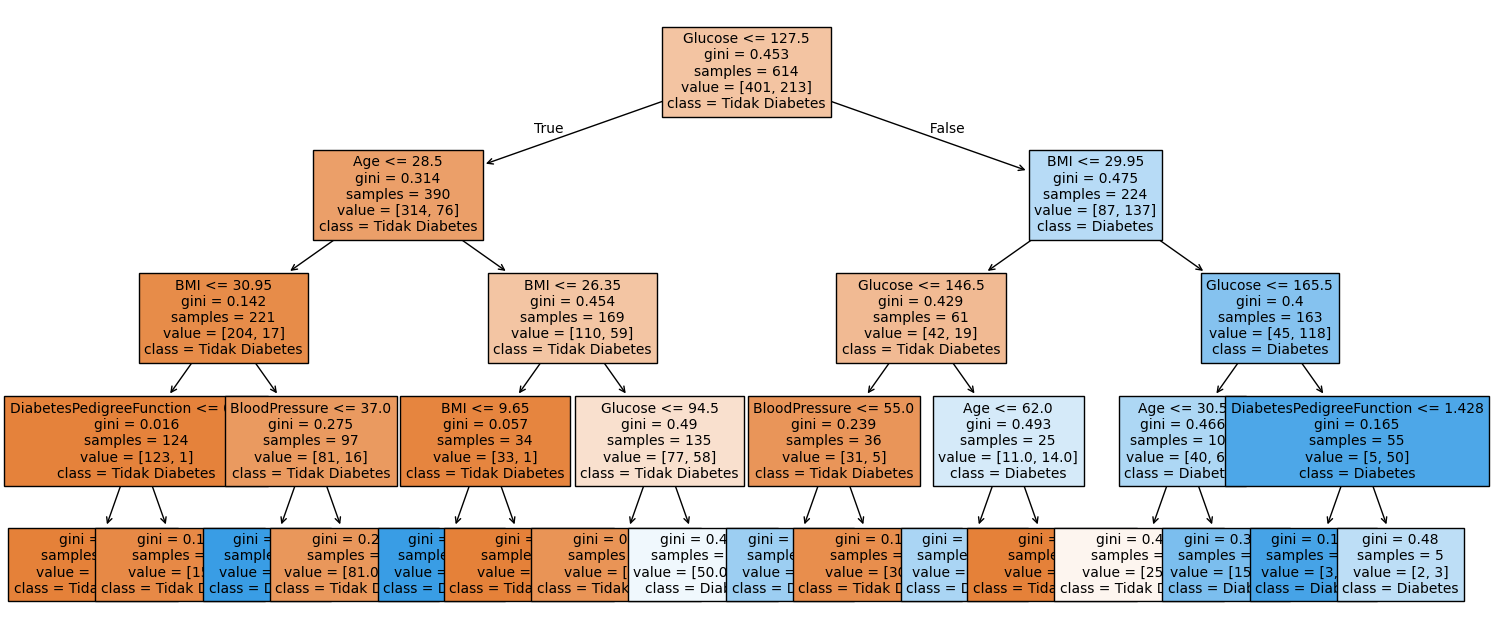

In [ ]:
from  sklearn.tree import plot_tree
plt.figure(figsize=(18, 8))
plot_tree(model, filled=True, feature_names=X.columns, fontsize=10, class_names=['Tidak Diabetes','Diabetes'])
plt.show()